In [ ]:
!pip install pandas numpy nltk scikit-learn imbalanced-learn gdown tensorflow emoji

<h1>Loading the data and checking the shape</h1>


In [ ]:
import pandas as pd

df = pd.read_csv("/kaggle/input/datasets/peesalanaveen/mental-health-dataset/Mental-health-related-subreddits.csv")

display(df.head())
print(df.shape)

/tmp/ipykernel_17/2508745073.py:3: DtypeWarning: Columns (3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("/kaggle/input/datasets/peesalanaveen/mental-health-dataset/Mental-health-related-subreddits.csv")


,Title,Text,Subreddit,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 69,Unnamed: 70,Unnamed: 71,Unnamed: 72,Unnamed: 73,Unnamed: 74,Unnamed: 75,Unnamed: 76,Unnamed: 77,Unnamed: 78
0,exposure does not work!,I have struggled with social anxiety from chil...,Anxiety,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Panic attack? derealization? can't go to docto...,"Back in March (I know, a while ago D:), I woke...",Anxiety,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,How long can a panic attack last?!,I've been withdrawing from medicines lately (e...,Anxiety,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Stepping stones,"First time poster, long time lurker. \n\nI've ...",Anxiety,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,"Coping with anxiety over climate change, on th...","Hi all,\n\nI made a throwaway account as my ma...",Anxiety,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


(488738, 79)


In [ ]:
df = df.loc[:, ~df.columns.str.startswith("Unnamed")]

In [ ]:
print(df.shape)
print(df.columns)
df.info()

(488738, 3)
Index(['Title', 'Text', 'Subreddit'], dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 488738 entries, 0 to 488737
Data columns (total 3 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   Title      488608 non-null  object
 1   Text       488573 non-null  object
 2   Subreddit  488535 non-null  object
dtypes: object(3)
memory usage: 11.2+ MB


In [ ]:
df = df.dropna()

print(df.isnull().sum())

Title        0
Text         0
Subreddit    0
dtype: int64


In [ ]:
valid_labels = [
    "depression",
    "mentalhealth",
    "Anxiety",
    "bipolar",
    "BPD",
    "schizophrenia",
    "autism"
]

# normalize text (very important)
df["Subreddit"] = df["Subreddit"].astype(str).str.strip()

# keep only valid labels
df = df[df["Subreddit"].isin(valid_labels)]

df = df[df["Subreddit"] != "mentalhealth"]

df["Subreddit"].value_counts()

Subreddit
depression       258490
Anxiety           86242
bipolar           41490
BPD               38210
schizophrenia     17505
autism             7142
Name: count, dtype: int64

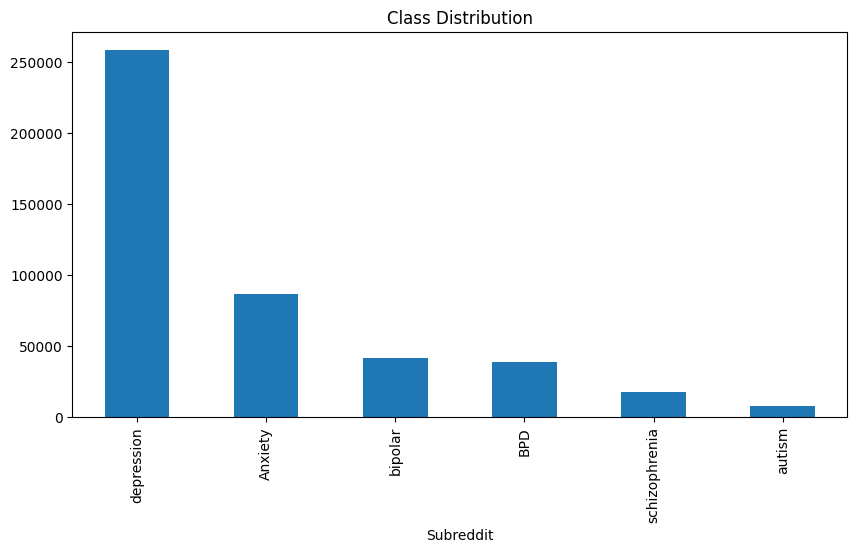

In [ ]:
import matplotlib.pyplot as plt

df["Subreddit"].value_counts().plot(kind="bar", figsize=(10,5))
plt.title("Class Distribution")
plt.show()

<h3>Text Length Analysis</h3>

In [ ]:
df["text_length"] = df["Text"].apply(lambda x: len(str(x).split()))

df["text_length"].describe()

count    449079.000000
mean        184.987488
std         224.415564
min           0.000000
25%          60.000000
50%         121.000000
75%         229.000000
max        6597.000000
Name: text_length, dtype: float64

🚨 Key Observations
1️⃣ Highly Skewed Distribution

👉 Most posts are short-medium (50–300 words)

👉 Few extremely long posts → outliers

3️⃣ Long tail problem

👉 Posts with:  

1000+ words

7000+ words

❌ These add noise
❌ Increase TF-IDF sparsity
❌ Hurt Naive Bayes performance

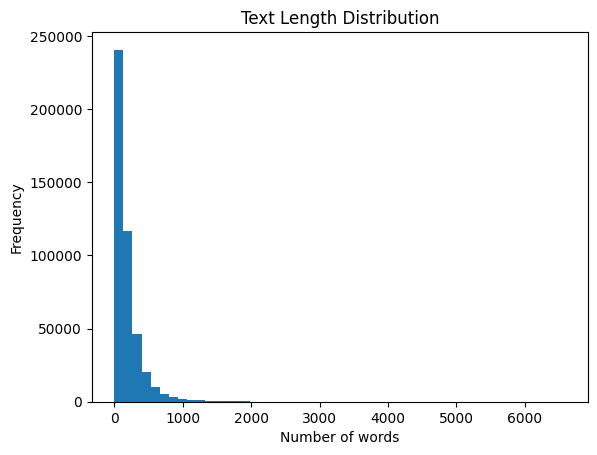

In [ ]:
import matplotlib.pyplot as plt

plt.hist(df["text_length"], bins=50)
plt.title("Text Length Distribution")
plt.xlabel("Number of words")
plt.ylabel("Frequency")
plt.show()

🎯 Decision (VERY IMPORTANT)

For Naive Bayes, we will:

✔️ Remove empty texts

✔️ Limit max text length (trim very long posts)

<h3>Removing the Posts with 0 words</h3>

In [ ]:
df = df[df["text_length"] > 0]
print(df.shape)

(449000, 4)


<h3>Triming the long text</h3>

In [ ]:
def trim_text(text, max_words=500):
    words = text.split()
    return " ".join(words[:max_words])

df["Text"] = df["Text"].apply(trim_text)
df.shape

(449000, 4)

<h3>Merge Title + Text</h3>

In [ ]:
df["content"] = df["Title"] + " " + df["Text"]

<h3>Clean Text</h3>

In [ ]:
import re

def clean_text(text):
    text = str(text).lower()  # Convert to string before applying lower()
    text = re.sub(r"http\S+|www\S+", "", text)
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["clean_text"] = df["content"].apply(clean_text)

In [ ]:
df["clean_text"]

0         exposure does not work i have struggled with s...
1         panic attack derealization cant go to doctors ...
2         how long can a panic attack last ive been with...
3         stepping stones first time poster long time lu...
4         coping with anxiety over climate change on the...
                                ...                        
488733    religion and paranoid conversation ok ive got ...
488734    isnt this a little weird for being tardive dys...
488735    is this a symptom of schizophrenia or somethin...
488736    anyone seen the new black mirror episode bande...
488737    my girlfriend of over year and i just broke up...
Name: clean_text, Length: 449000, dtype: object

<h3>Remove Stopwords</h3>

In [ ]:
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

def remove_stopwords(text):
    return " ".join([word for word in text.split() if word not in ENGLISH_STOP_WORDS])

df["clean_text"] = df["clean_text"].apply(remove_stopwords)

In [ ]:
df["clean_text"].head()

0    exposure does work struggled social anxiety ch...
1    panic attack derealization doctors advice appr...
2    long panic attack ive withdrawing medicines la...
3    stepping stones time poster long time lurker i...
4    coping anxiety climate change verge considerin...
Name: clean_text, dtype: object

<h3>Encode Labels</h3>

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df["label"] = le.fit_transform(df["Subreddit"])

print(dict(zip(le.classes_, le.transform(le.classes_))))

{'Anxiety': np.int64(0), 'BPD': np.int64(1), 'autism': np.int64(2), 'bipolar': np.int64(3), 'depression': np.int64(4), 'schizophrenia': np.int64(5)}


<h3>Split</h3>

In [ ]:
from sklearn.model_selection import train_test_split

X = df["clean_text"]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(X_train.shape, X_test.shape)

(359200,) (89800,)


<h3>Tokenization + Padding</h3>

In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

MAX_WORDS = 50000
MAX_LEN = 100   # you can tune (100–200 is good)

tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=MAX_LEN, padding='post')

2026-04-08 11:37:21.909801: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775648242.210096      17 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775648242.293249      17 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775648242.970864      17 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775648242.970902      17 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775648242.970911      17 computation_placer.cc:177] computation placer alr

<h3>APPLY SMOTE</h3>

In [ ]:
from imblearn.over_sampling import SMOTE

# reshape to 2D
nsamples, nx = X_train_pad.shape
X_train_reshaped = X_train_pad.reshape((nsamples, nx))

smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_train_reshaped, y_train)

# reshape back
X_resampled = X_resampled.reshape((-1, MAX_LEN))

<h3>Build embedding matrix</h3>

In [ ]:
import numpy as np

embedding_index = {}

with open("/kaggle/input/datasets/peesalanaveen/glove-6b/glove.6B.100d.txt", encoding="utf-8") as f:
    for line in f:
        values = line.split()
        word = values[0]
        vector = np.asarray(values[1:], dtype="float32")
        embedding_index[word] = vector

embedding_dim = 100
word_index = tokenizer.word_index

embedding_matrix = np.zeros((len(word_index)+1, embedding_dim))

for word, i in word_index.items():
    vector = embedding_index.get(word)
    if vector is not None:
        embedding_matrix[i] = vector

<h3>Build BiLSTM</h3>

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout, SpatialDropout1D

model = Sequential()

model.add(Embedding(
    input_dim=len(word_index)+1,
    output_dim=100,
    weights=[embedding_matrix],
    input_length=MAX_LEN,
    trainable=False
))

model.add(SpatialDropout1D(0.3))

model.add(Bidirectional(LSTM(128, return_sequences=True)))

model.add(Bidirectional(LSTM(64)))

model.add(Dropout(0.5))

model.add(Dense(64, activation='relu'))

model.add(Dense(6, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
2026-04-08 11:40:41.178621: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


<h3>Train Model</h3>

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

history = model.fit(
    X_resampled,
    y_resampled,
    epochs=2,
    batch_size=128,
    validation_data=(X_test_pad, y_test),
    callbacks=[early_stop]
)

Epoch 1/2
9692/9692 ━━━━━━━━━━━━━━━━━━━━ 5167s 532ms/step - accuracy: 0.3824 - loss: 1.4578 - val_accuracy: 0.7917 - val_loss: 0.6644
Epoch 2/2
9692/9692 ━━━━━━━━━━━━━━━━━━━━ 5213s 538ms/step - accuracy: 0.4491 - loss: 1.2946 - val_accuracy: 0.8075 - val_loss: 0.5994


<h3>Evaluate</h3>

In [ ]:
from sklearn.metrics import classification_report, f1_score, accuracy_score
import pandas as pd
import numpy as np

y_pred = model.predict(X_test_pad)
y_pred_classes = y_pred.argmax(axis=1)

# Get class names from the LabelEncoder
class_names = le.classes_

results = []

for i, class_name in enumerate(class_names):
    # One-vs-rest approach
    y_true_binary = (y_test == i)
    y_pred_binary = (y_pred_classes == i)

    # Calculate F1 for the current class (positive label)
    class_f1 = f1_score(y_true_binary, y_pred_binary, pos_label=True)

    # Calculate F1 for the non-class (negative label)
    non_class_f1 = f1_score(y_true_binary, y_pred_binary, pos_label=False)

    # Calculate accuracy for the current class
    class_accuracy = accuracy_score(y_true_binary, y_pred_binary)

    results.append({
        'Class': class_name,
        'Non-Class F1': non_class_f1,
        'Class F1': class_f1,
        'Class Accuracy': class_accuracy
    })

# Create a DataFrame from the results
f1_df = pd.DataFrame(results)

print("Evaluation Metrics Per Class:")
display(f1_df)

# Calculate and print overall accuracy
accuracy = accuracy_score(y_test, y_pred_classes)
print(f"\nOverall Model Accuracy: {accuracy:.6f}")

2807/2807 ━━━━━━━━━━━━━━━━━━━━ 229s 81ms/step
Evaluation Metrics Per Class:


,Class,Non-Class F1,Class F1,Class Accuracy
0,Anxiety,0.950242,0.781651,0.918953
1,BPD,0.972513,0.623209,0.948764
2,autism,0.996136,0.733852,0.992383
3,bipolar,0.973411,0.696230,0.951102
4,depression,0.797790,0.870682,0.842249
5,schizophrenia,0.979920,0.538462,0.961514



Overall Model Accuracy: 0.807483


<h3>Accuracy Table</h3>

In [ ]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred_classes)
print("Accuracy:", accuracy)

Accuracy: 0.8074832962138084
